In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv('global_youtube_creator_data_large.csv')
data

,timestamp,video_id,category,language,region,duration_sec,views,likes,comments,shares,sentiment_score,ads_enabled
0,2024-09-14 05:08:02,VID_589765,Vlogs,Japanese,PK,873,6826,396,34,31,-0.082,True
1,2025-08-09 12:23:26,VID_577279,Tech Reviews,Urdu,UK,2335,11371,402,26,19,-0.873,False
2,2024-03-04 14:39:48,VID_890301,Gaming,English,BR,1895,7509,730,45,25,-0.764,True
3,2025-05-04 11:05:26,VID_613444,Education,Urdu,PK,841,17361,1302,122,25,-0.788,True
4,2024-09-22 20:22:31,VID_602671,Gaming,Japanese,IN,1246,18494,756,63,42,0.521,False
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2024-06-25 13:51:46,VID_383631,Tech Reviews,Urdu,IN,3052,9019,345,58,9,0.122,True
999996,2025-05-25 06:00:30,VID_415513,Gaming,Japanese,BR,3145,1831,104,12,2,0.043,False
999997,2025-07-16 23:45:41,VID_638447,Gaming,English,US,2269,17,1,0,0,-0.784,False
999998,2025-01-07 21:06:01,VID_177749,Education,Urdu,UK,1351,7355,555,54,34,0.978,True


In [4]:
df=pd.read_csv('global_youtube_creator_data_large.csv')

In [5]:
# !pip install 
df.size

12000000

# **Data** **Cleaning**

In [6]:
df.head()

,timestamp,video_id,category,language,region,duration_sec,views,likes,comments,shares,sentiment_score,ads_enabled
0,2024-09-14 05:08:02,VID_589765,Vlogs,Japanese,PK,873,6826,396,34,31,-0.082,True
1,2025-08-09 12:23:26,VID_577279,Tech Reviews,Urdu,UK,2335,11371,402,26,19,-0.873,False
2,2024-03-04 14:39:48,VID_890301,Gaming,English,BR,1895,7509,730,45,25,-0.764,True
3,2025-05-04 11:05:26,VID_613444,Education,Urdu,PK,841,17361,1302,122,25,-0.788,True
4,2024-09-22 20:22:31,VID_602671,Gaming,Japanese,IN,1246,18494,756,63,42,0.521,False


In [7]:
data.describe()

,duration_sec,views,likes,comments,shares,sentiment_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000
mean,1829.589053,10012.587052,550.139094,68.34110,29.536169,0.000547
std,1022.387019,9999.381263,662.291287,90.89229,34.185734,0.577070
min,60.000000,0.000000,0.000000,0.00000,0.000000,-1.000000
25%,943.000000,2885.000000,121.000000,13.00000,7.000000,-0.499000
50%,1830.000000,6943.000000,321.000000,37.00000,18.000000,0.001000
75%,2715.000000,13877.000000,727.000000,87.00000,40.000000,0.500000
max,3599.000000,147139.000000,11970.000000,1795.00000,718.000000,1.000000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   timestamp        1000000 non-null  object 
 1   video_id         1000000 non-null  object 
 2   category         1000000 non-null  object 
 3   language         1000000 non-null  object 
 4   region           1000000 non-null  object 
 5   duration_sec     1000000 non-null  int64  
 6   views            1000000 non-null  int64  
 7   likes            1000000 non-null  int64  
 8   comments         1000000 non-null  int64  
 9   shares           1000000 non-null  int64  
 10  sentiment_score  1000000 non-null  float64
 11  ads_enabled      1000000 non-null  bool   
dtypes: bool(1), float64(1), int64(5), object(5)
memory usage: 84.9+ MB


In [9]:
data.isna().sum()

timestamp          0
video_id           0
category           0
language           0
region             0
duration_sec       0
views              0
likes              0
comments           0
shares             0
sentiment_score    0
ads_enabled        0
dtype: int64

In [10]:
df['timestamp']=pd.to_datetime(df['timestamp'])


In [11]:
df['year']=df['timestamp'].dt.year
df['month']=df['timestamp'].dt.month
df['day']=df['timestamp'].dt.day

In [12]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['video_id']=le.fit_transform(df['video_id'])
df['category']=le.fit_transform(df['category'])
df['language']=le.fit_transform(df['language'])
df['region']=le.fit_transform(df['region'])
df['ads_enabled']=le.fit_transform(df['ads_enabled'])

# Feature Engineering

In [13]:
df.size

15000000

In [14]:
df['engagement']=df['likes']+df['comments']+df['shares']

In [15]:
df['like_ratio'] = df['likes'] / df['views']

In [16]:
df['comment_ratio'] = df['comments'] / df['views']

In [17]:
df['share_ratio'] = df['shares'] / df['views']

In [18]:
df.head(10)

,timestamp,video_id,category,language,region,duration_sec,views,likes,comments,shares,sentiment_score,ads_enabled,year,month,day,engagement,like_ratio,comment_ratio,share_ratio
0,2024-09-14 05:08:02,328402,5,2,2,873,6826,396,34,31,-0.082,1,2024,9,14,461,0.058013,0.004981,0.004541
1,2025-08-09 12:23:26,319982,4,4,3,2335,11371,402,26,19,-0.873,0,2025,8,9,447,0.035353,0.002287,0.001671
2,2024-03-04 14:39:48,529826,2,0,0,1895,7509,730,45,25,-0.764,1,2024,3,4,800,0.097217,0.005993,0.003329
3,2025-05-04 11:05:26,344327,1,4,2,841,17361,1302,122,25,-0.788,1,2025,5,4,1449,0.074996,0.007027,0.001440
4,2024-09-22 20:22:31,337036,2,2,1,1246,18494,756,63,42,0.521,0,2024,9,22,861,0.040878,0.003407,0.002271
5,2024-07-03 11:35:49,410398,3,4,0,3166,6432,596,67,14,-0.042,1,2024,7,3,677,0.092662,0.010417,0.002177
6,2024-02-26 12:47:42,377884,0,3,3,223,32708,347,34,61,-0.306,0,2024,2,26,442,0.010609,0.001040,0.001865
7,2025-12-06 09:48:18,229116,1,4,1,2330,1989,183,28,4,0.550,1,2025,12,6,215,0.092006,0.014077,0.002011
8,2025-06-30 06:27:25,230088,5,3,1,1434,47413,1223,187,169,-0.671,1,2025,6,30,1579,0.025795,0.003944,0.003564
9,2025-04-06 23:44:44,554358,1,0,3,1370,10573,178,16,12,-0.768,1,2025,4,6,206,0.016835,0.001513,0.001135


In [19]:
df.isna().sum()

timestamp            0
video_id             0
category             0
language             0
region               0
duration_sec         0
views                0
likes                0
comments             0
shares               0
sentiment_score      0
ads_enabled          0
year                 0
month                0
day                  0
engagement           0
like_ratio         104
comment_ratio      104
share_ratio        104
dtype: int64

In [20]:
df.shape

(1000000, 19)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 19 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   timestamp        1000000 non-null  datetime64[ns]
 1   video_id         1000000 non-null  int64         
 2   category         1000000 non-null  int64         
 3   language         1000000 non-null  int64         
 4   region           1000000 non-null  int64         
 5   duration_sec     1000000 non-null  int64         
 6   views            1000000 non-null  int64         
 7   likes            1000000 non-null  int64         
 8   comments         1000000 non-null  int64         
 9   shares           1000000 non-null  int64         
 10  sentiment_score  1000000 non-null  float64       
 11  ads_enabled      1000000 non-null  int64         
 12  year             1000000 non-null  int32         
 13  month            1000000 non-null  int32         
 14  day

In [22]:
df['like_ratio'] = df['like_ratio'].fillna(df['like_ratio'].median())
df['comment_ratio'] = df['comment_ratio'].fillna(df['comment_ratio'].median())
df['share_ratio'] = df['share_ratio'].fillna(df['share_ratio'].median())

In [23]:
df.isna().sum()

timestamp          0
video_id           0
category           0
language           0
region             0
duration_sec       0
views              0
likes              0
comments           0
shares             0
sentiment_score    0
ads_enabled        0
year               0
month              0
day                0
engagement         0
like_ratio         0
comment_ratio      0
share_ratio        0
dtype: int64

# Visualization

<Axes: xlabel='category', ylabel='views'>

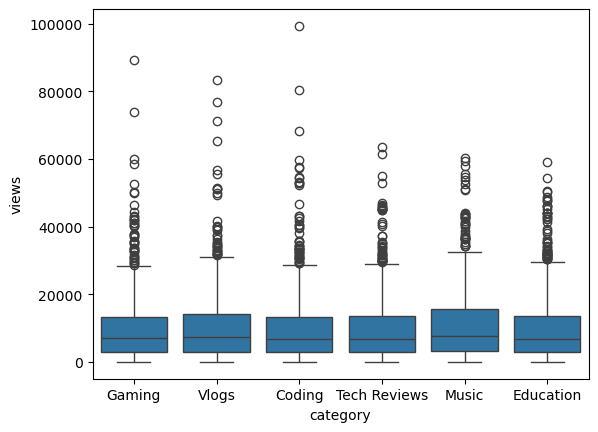

In [24]:
sample = data.sample(5000)
sns.boxplot(x='category',y='views',data=sample)

<Axes: xlabel='category', ylabel='views'>

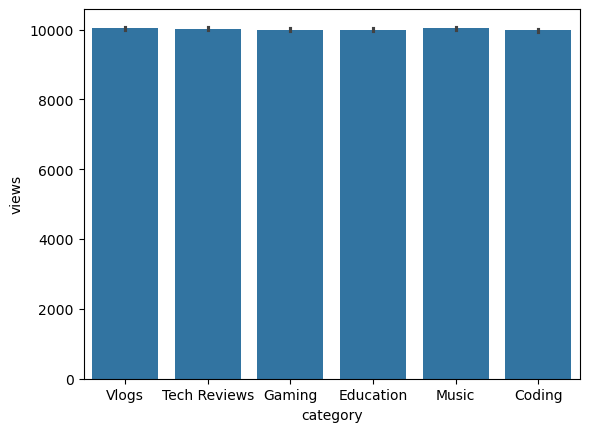

In [25]:
sns.barplot(x='category',y='views',data=data)

<Axes: xlabel='sentiment_score', ylabel='views'>

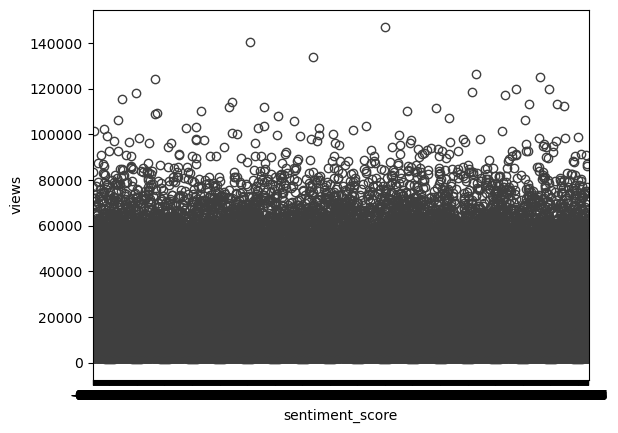

In [26]:
sns.boxplot(x='sentiment_score',y='views',data=data)

<Axes: xlabel='sentiment_score', ylabel='views'>

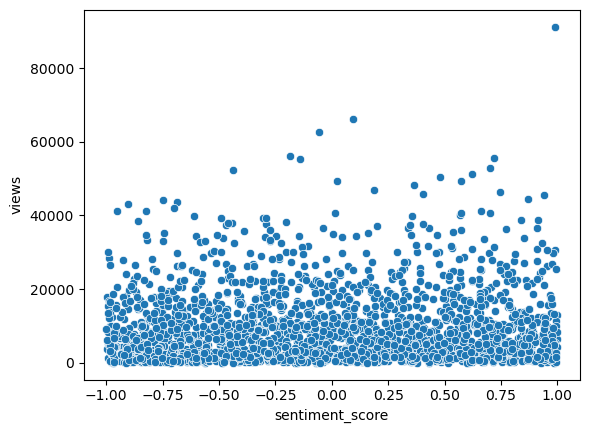

In [27]:
sample = data.sample(2000)

sns.scatterplot(x='sentiment_score', y='views', data=sample)

<Axes: >

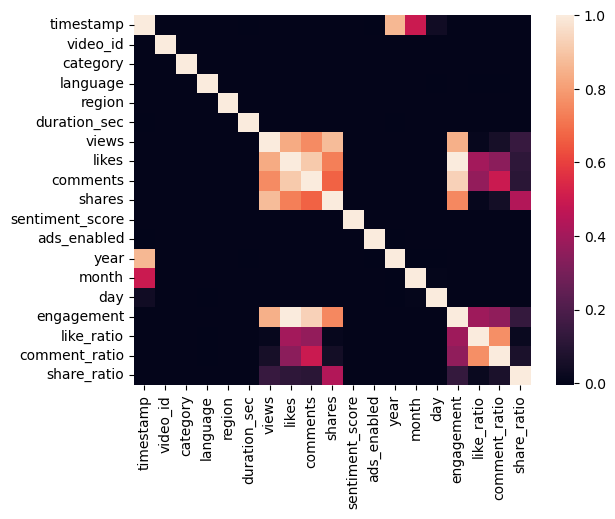

In [28]:
sns.heatmap(df.corr())


# Regression

In [29]:
x=df.drop(['views','video_id','timestamp'], axis=1)
y=df['views']

In [30]:
x.shape

(1000000, 16)

In [31]:
y.shape

(1000000,)

In [32]:
x.isna().sum()

category           0
language           0
region             0
duration_sec       0
likes              0
comments           0
shares             0
sentiment_score    0
ads_enabled        0
year               0
month              0
day                0
engagement         0
like_ratio         0
comment_ratio      0
share_ratio        0
dtype: int64

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)

# Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
pred= lr.predict(X_test)

In [35]:
from sklearn.metrics import mean_squared_error , r2_score , mean_absolute_error
lr_r2=r2_score(y_test,pred)
lr_mean_ab=mean_absolute_error(y_test,pred)
lr_mean_sq=mean_squared_error(y_test,pred)
print(lr_r2)
print(lr_mean_ab)
print(lr_mean_sq)

0.9058233419433676
1833.4925264478725
9408089.814768577


In [36]:
X_test.size

3200000

In [37]:
X_test.shape

(200000, 16)

In [38]:
y_test.shape

(200000,)

In [39]:
y_test.size

200000

In [40]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("pred shape:", pred.shape)

X_test shape: (200000, 16)
y_test shape: (200000,)
pred shape: (200000,)


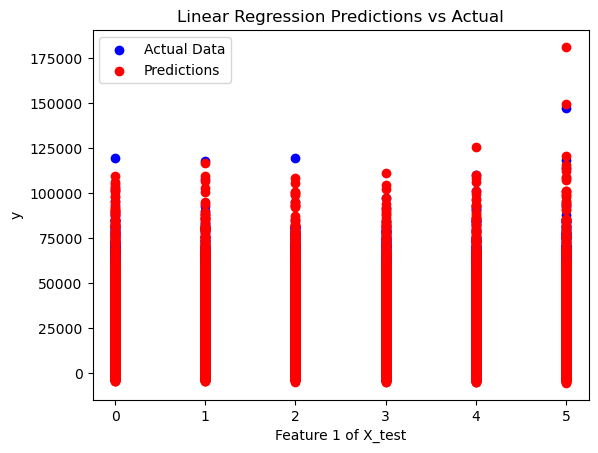

In [41]:
plt.scatter(X_test.iloc[:,0], y_test, color='blue', label='Actual Data')
plt.scatter(X_test.iloc[:,0], pred, color='red', label='Predictions')
plt.xlabel('Feature 1 of X_test')
plt.ylabel('y')
plt.title('Linear Regression Predictions vs Actual')
plt.legend()
plt.show()

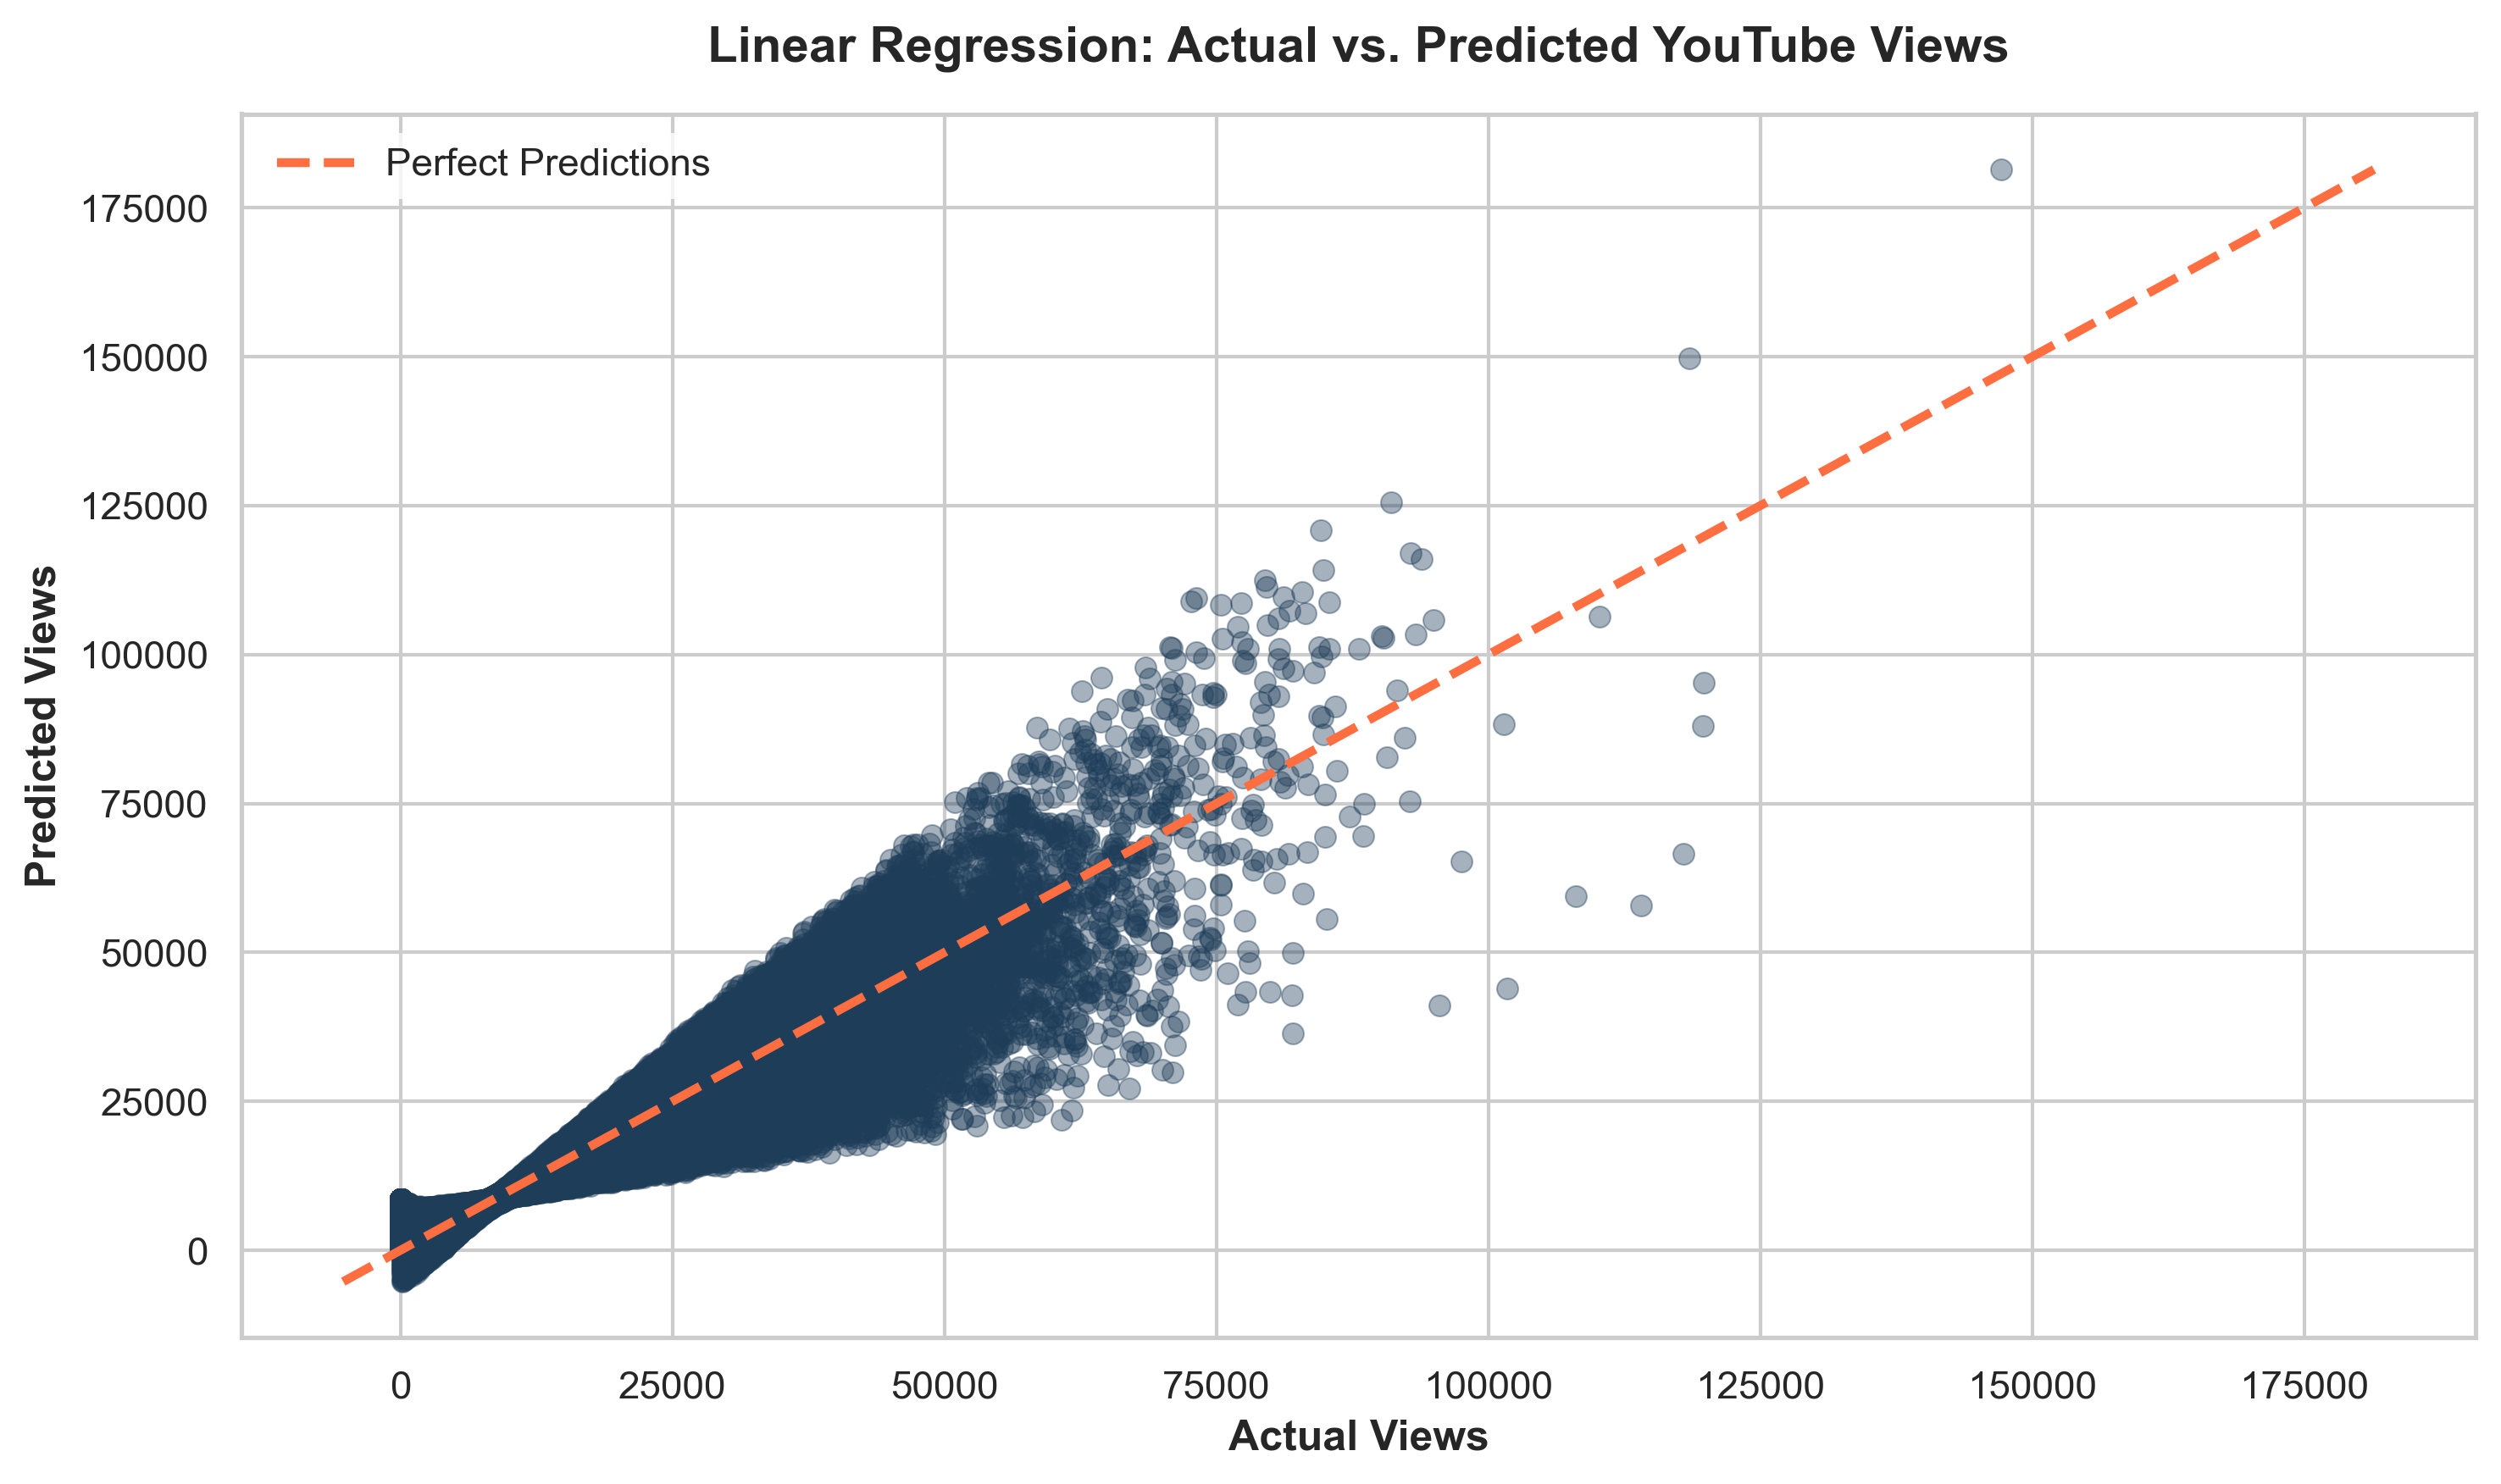

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set high resolution for professional display
plt.figure(figsize=(10, 6), dpi=300)
sns.set_theme(style="whitegrid")

# Plot the scatter points with transparency for density visualization

sns.scatterplot(x=y_test, y=pred, alpha=0.4, color="#1e3d59", edgecolor=None)

# Draw the perfect prediction line (Where Actual = Predicted)
max_val = max(max(y_test), max(pred))
min_val = min(min(y_test), min(pred))
plt.plot([min_val, max_val], [min_val, max_val], color='#ff6e40', linestyle='--', linewidth=2.5, label='Perfect Predictions')

# English titles and labels
plt.title('Linear Regression: Actual vs. Predicted YouTube Views', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Actual Views', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Views', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Save the high-res image directly to your folder
plt.savefig('linear_regression_perf.png', dpi=300)
plt.show()

# Decision Tree Regressor

In [42]:
from sklearn.tree import DecisionTreeRegressor
Dece=DecisionTreeRegressor(criterion='squared_error',max_depth=10, min_samples_split=20 , min_samples_leaf=10 ,random_state=42)
Dece.fit(X_train, y_train)
pred_De = Dece.predict(X_test)

In [43]:
from sklearn.metrics import mean_squared_error , r2_score , mean_absolute_error
Dece_r2=r2_score(y_test,pred_De)
Dece_mean_ab=mean_absolute_error(y_test,pred_De)
Dece_mean_sq=mean_squared_error(y_test,pred_De)
print(Dece_r2)
print(Dece_mean_ab)
print(Dece_mean_sq)

0.9977821980994338
269.42450963784444
221554.6814088871


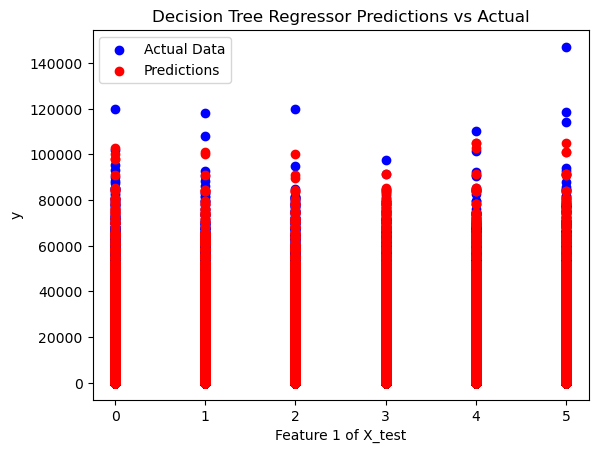

In [44]:
plt.scatter(X_test.iloc[:,0], y_test, color='blue', label='Actual Data')
plt.scatter(X_test.iloc[:,0], pred_De, color='red', label='Predictions')
plt.xlabel('Feature 1 of X_test')
plt.ylabel('y')
plt.title('Decision Tree Regressor Predictions vs Actual')
plt.legend()
plt.show()

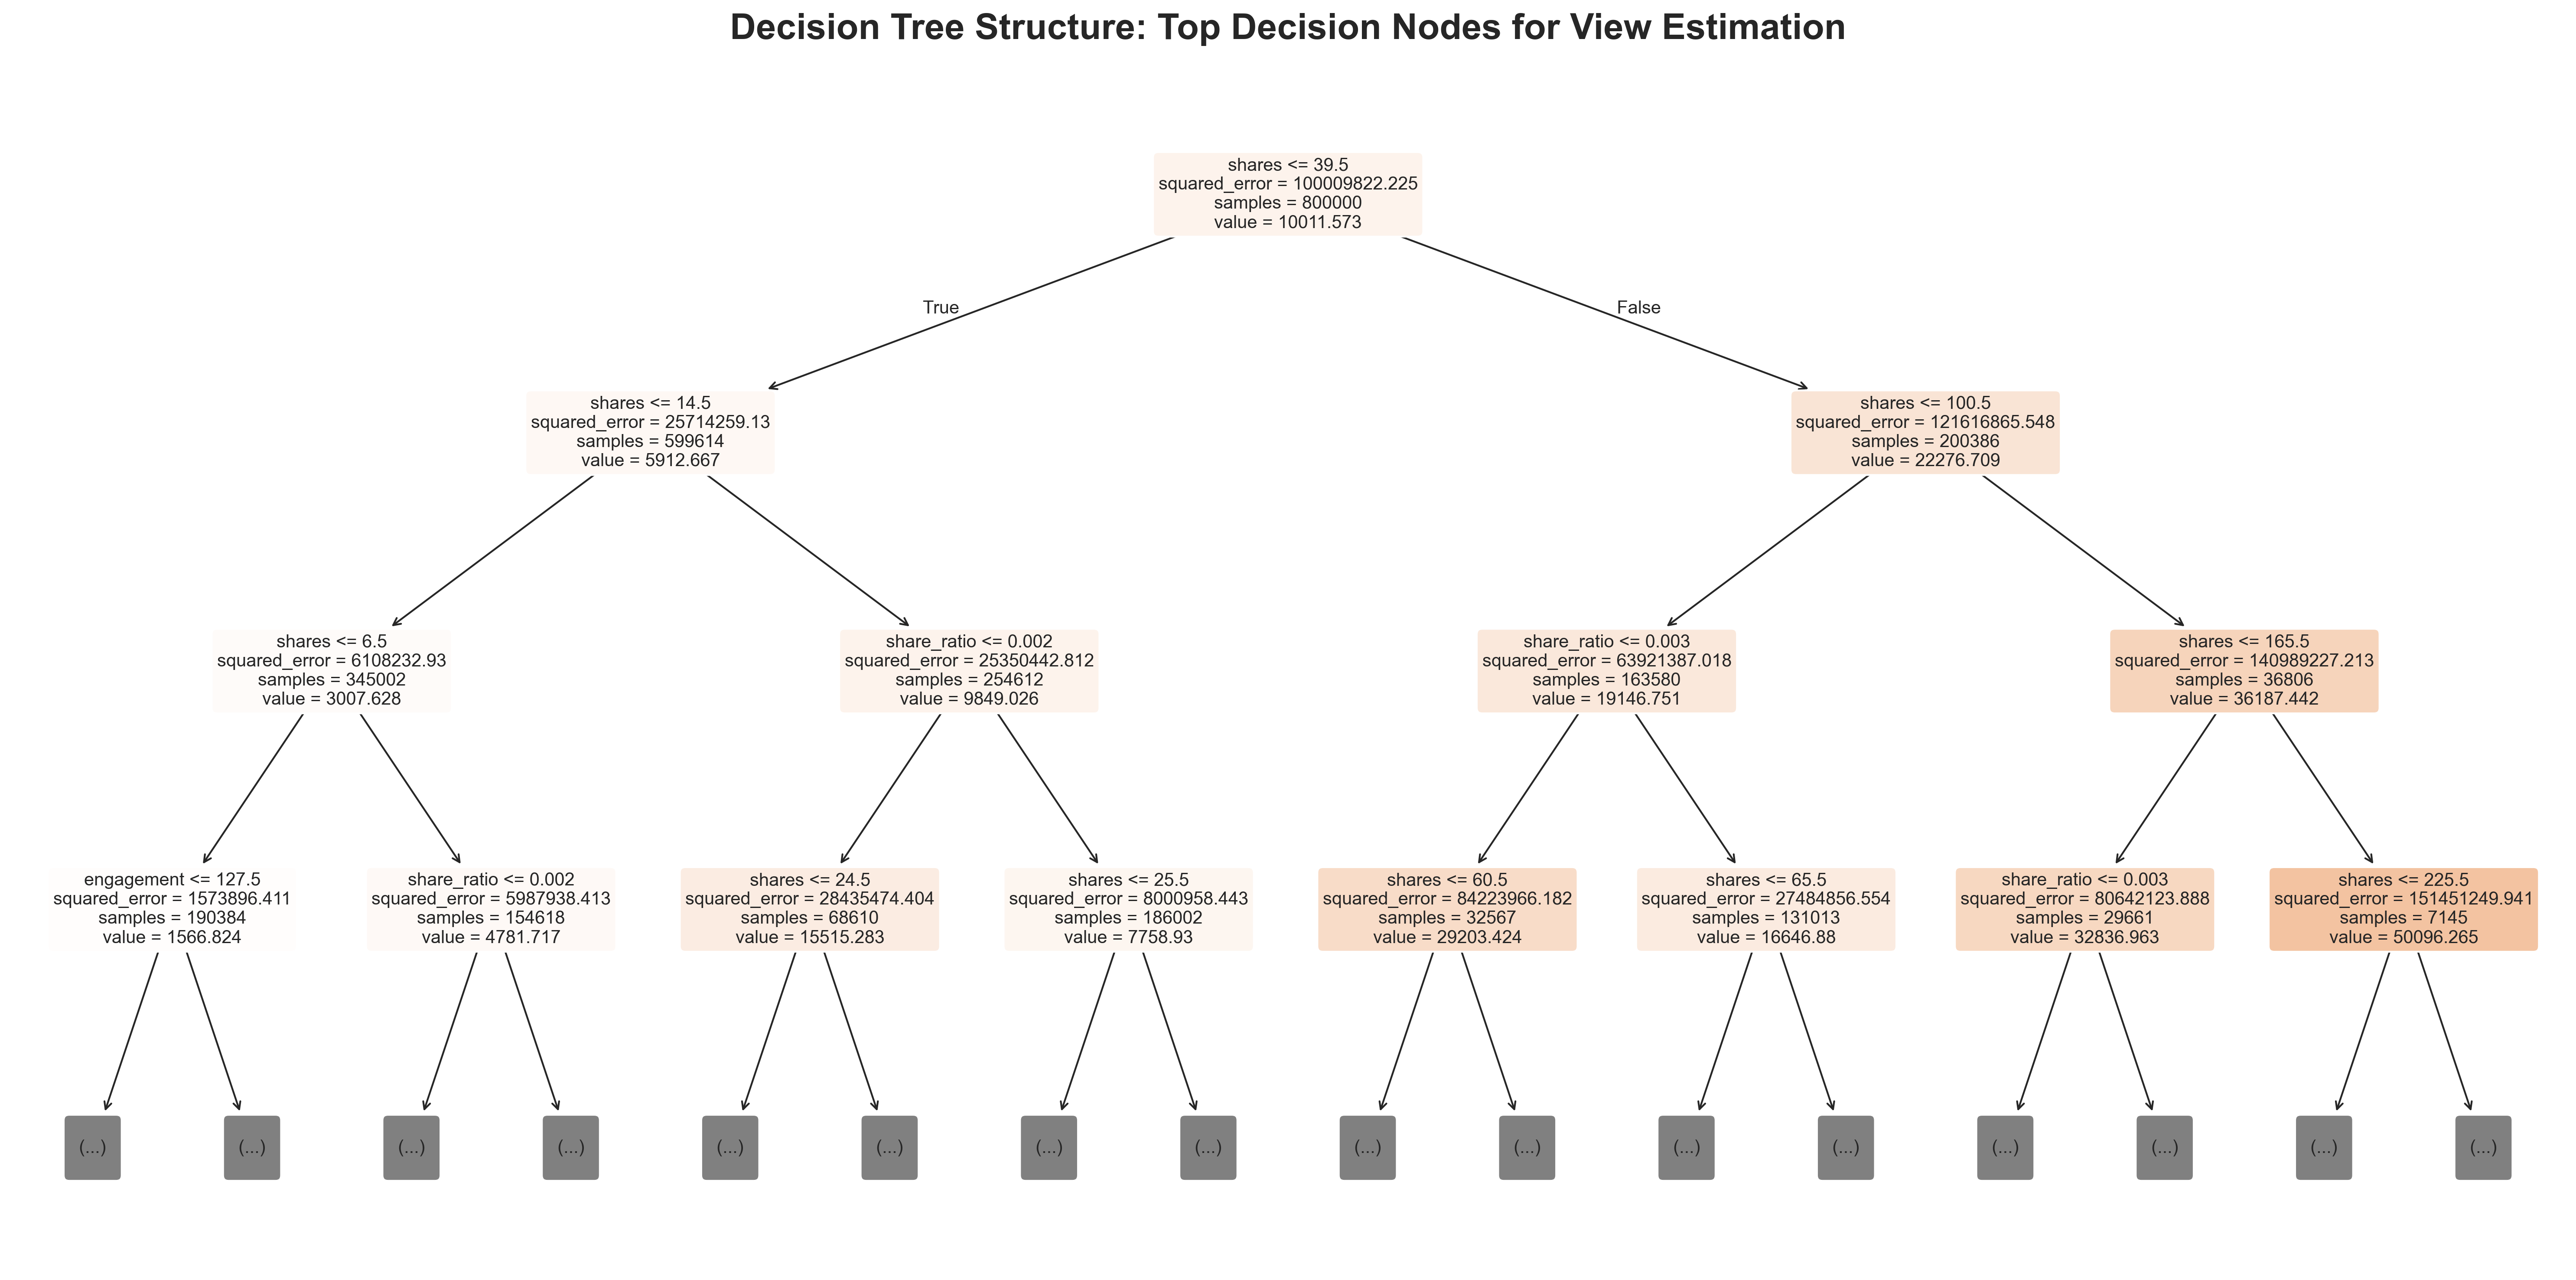

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Create the figure with high resolution
plt.figure(figsize=(20, 10), dpi=300)



plot_tree(Dece, 
          max_depth=3, 
          feature_names=X_train.columns, 
          filled=True, 
          rounded=True, 
          fontsize=10) 

# Set the English title for the portfolio
plt.title('Decision Tree Structure: Top Decision Nodes for View Estimation', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()

# Save the high-res image directly to your folder
plt.savefig('decision_tree_structure.png', dpi=300, bbox_inches='tight')
plt.show()

# Random Forest Regressor

In [45]:
from sklearn.ensemble import RandomForestRegressor
RF=RandomForestRegressor(n_estimators = 100 , max_depth = 10)
RF.fit(X_train,y_train)
pred_RF=RF.predict(X_test)

In [46]:
from sklearn.metrics import mean_squared_error , r2_score , mean_absolute_error
RF_r2=r2_score(y_test,pred_RF)
RF_mean_ab=mean_absolute_error(y_test,pred_RF)
RF_mean_sq=mean_squared_error(y_test,pred_RF)
print(RF_r2)
print(RF_mean_ab)
print(RF_mean_sq)

0.9993869010220069
144.5451494051896
61247.55719016748


In [47]:
result = X_test.copy()

result['real_views'] = y_test

result['predicted_views'] = pred_RF

result.head(5)

,category,language,region,duration_sec,likes,comments,shares,sentiment_score,ads_enabled,year,month,day,engagement,like_ratio,comment_ratio,share_ratio,real_views,predicted_views
987231,3,3,2,1633,1381,261,23,-0.456,1,2025,8,27,1665,0.075638,0.014295,0.001260,18258,18727.088255
79954,0,2,3,589,653,56,110,-0.089,1,2025,2,20,819,0.012886,0.001105,0.002171,50677,50242.302405
567130,4,3,0,1382,627,92,37,0.049,0,2024,1,30,756,0.023154,0.003397,0.001366,27079,26445.145337
500891,1,2,0,2247,924,144,37,0.901,1,2024,1,20,1105,0.066227,0.010321,0.002652,13952,13859.703754
55399,2,3,1,528,699,69,31,0.042,1,2024,2,29,799,0.044137,0.004357,0.001957,15837,15363.648531


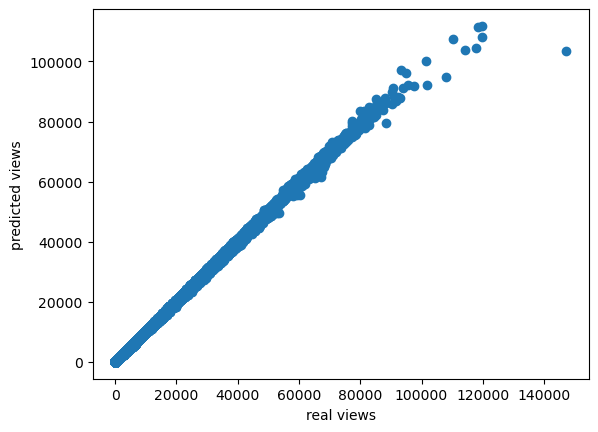

In [48]:
import matplotlib.pyplot as plt

plt.scatter(y_test,pred_RF)

plt.xlabel("real views")

plt.ylabel("predicted views")

plt.show()

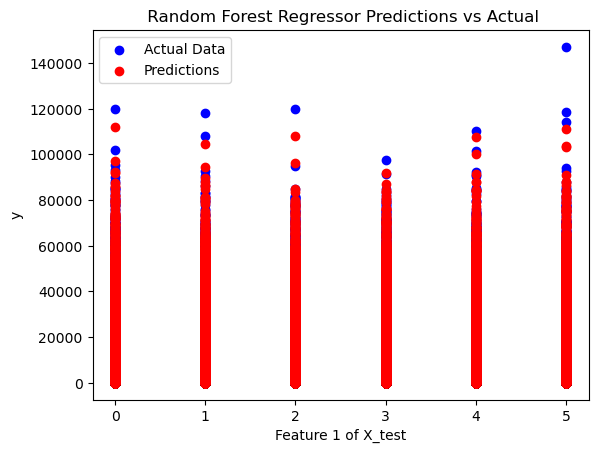

In [49]:
plt.scatter(X_test.iloc[:,0], y_test, color='blue', label='Actual Data')
plt.scatter(X_test.iloc[:,0], pred_RF, color='red', label='Predictions')
plt.xlabel('Feature 1 of X_test')
plt.ylabel('y')
plt.title(' Random Forest Regressor Predictions vs Actual')
plt.legend()
plt.show()

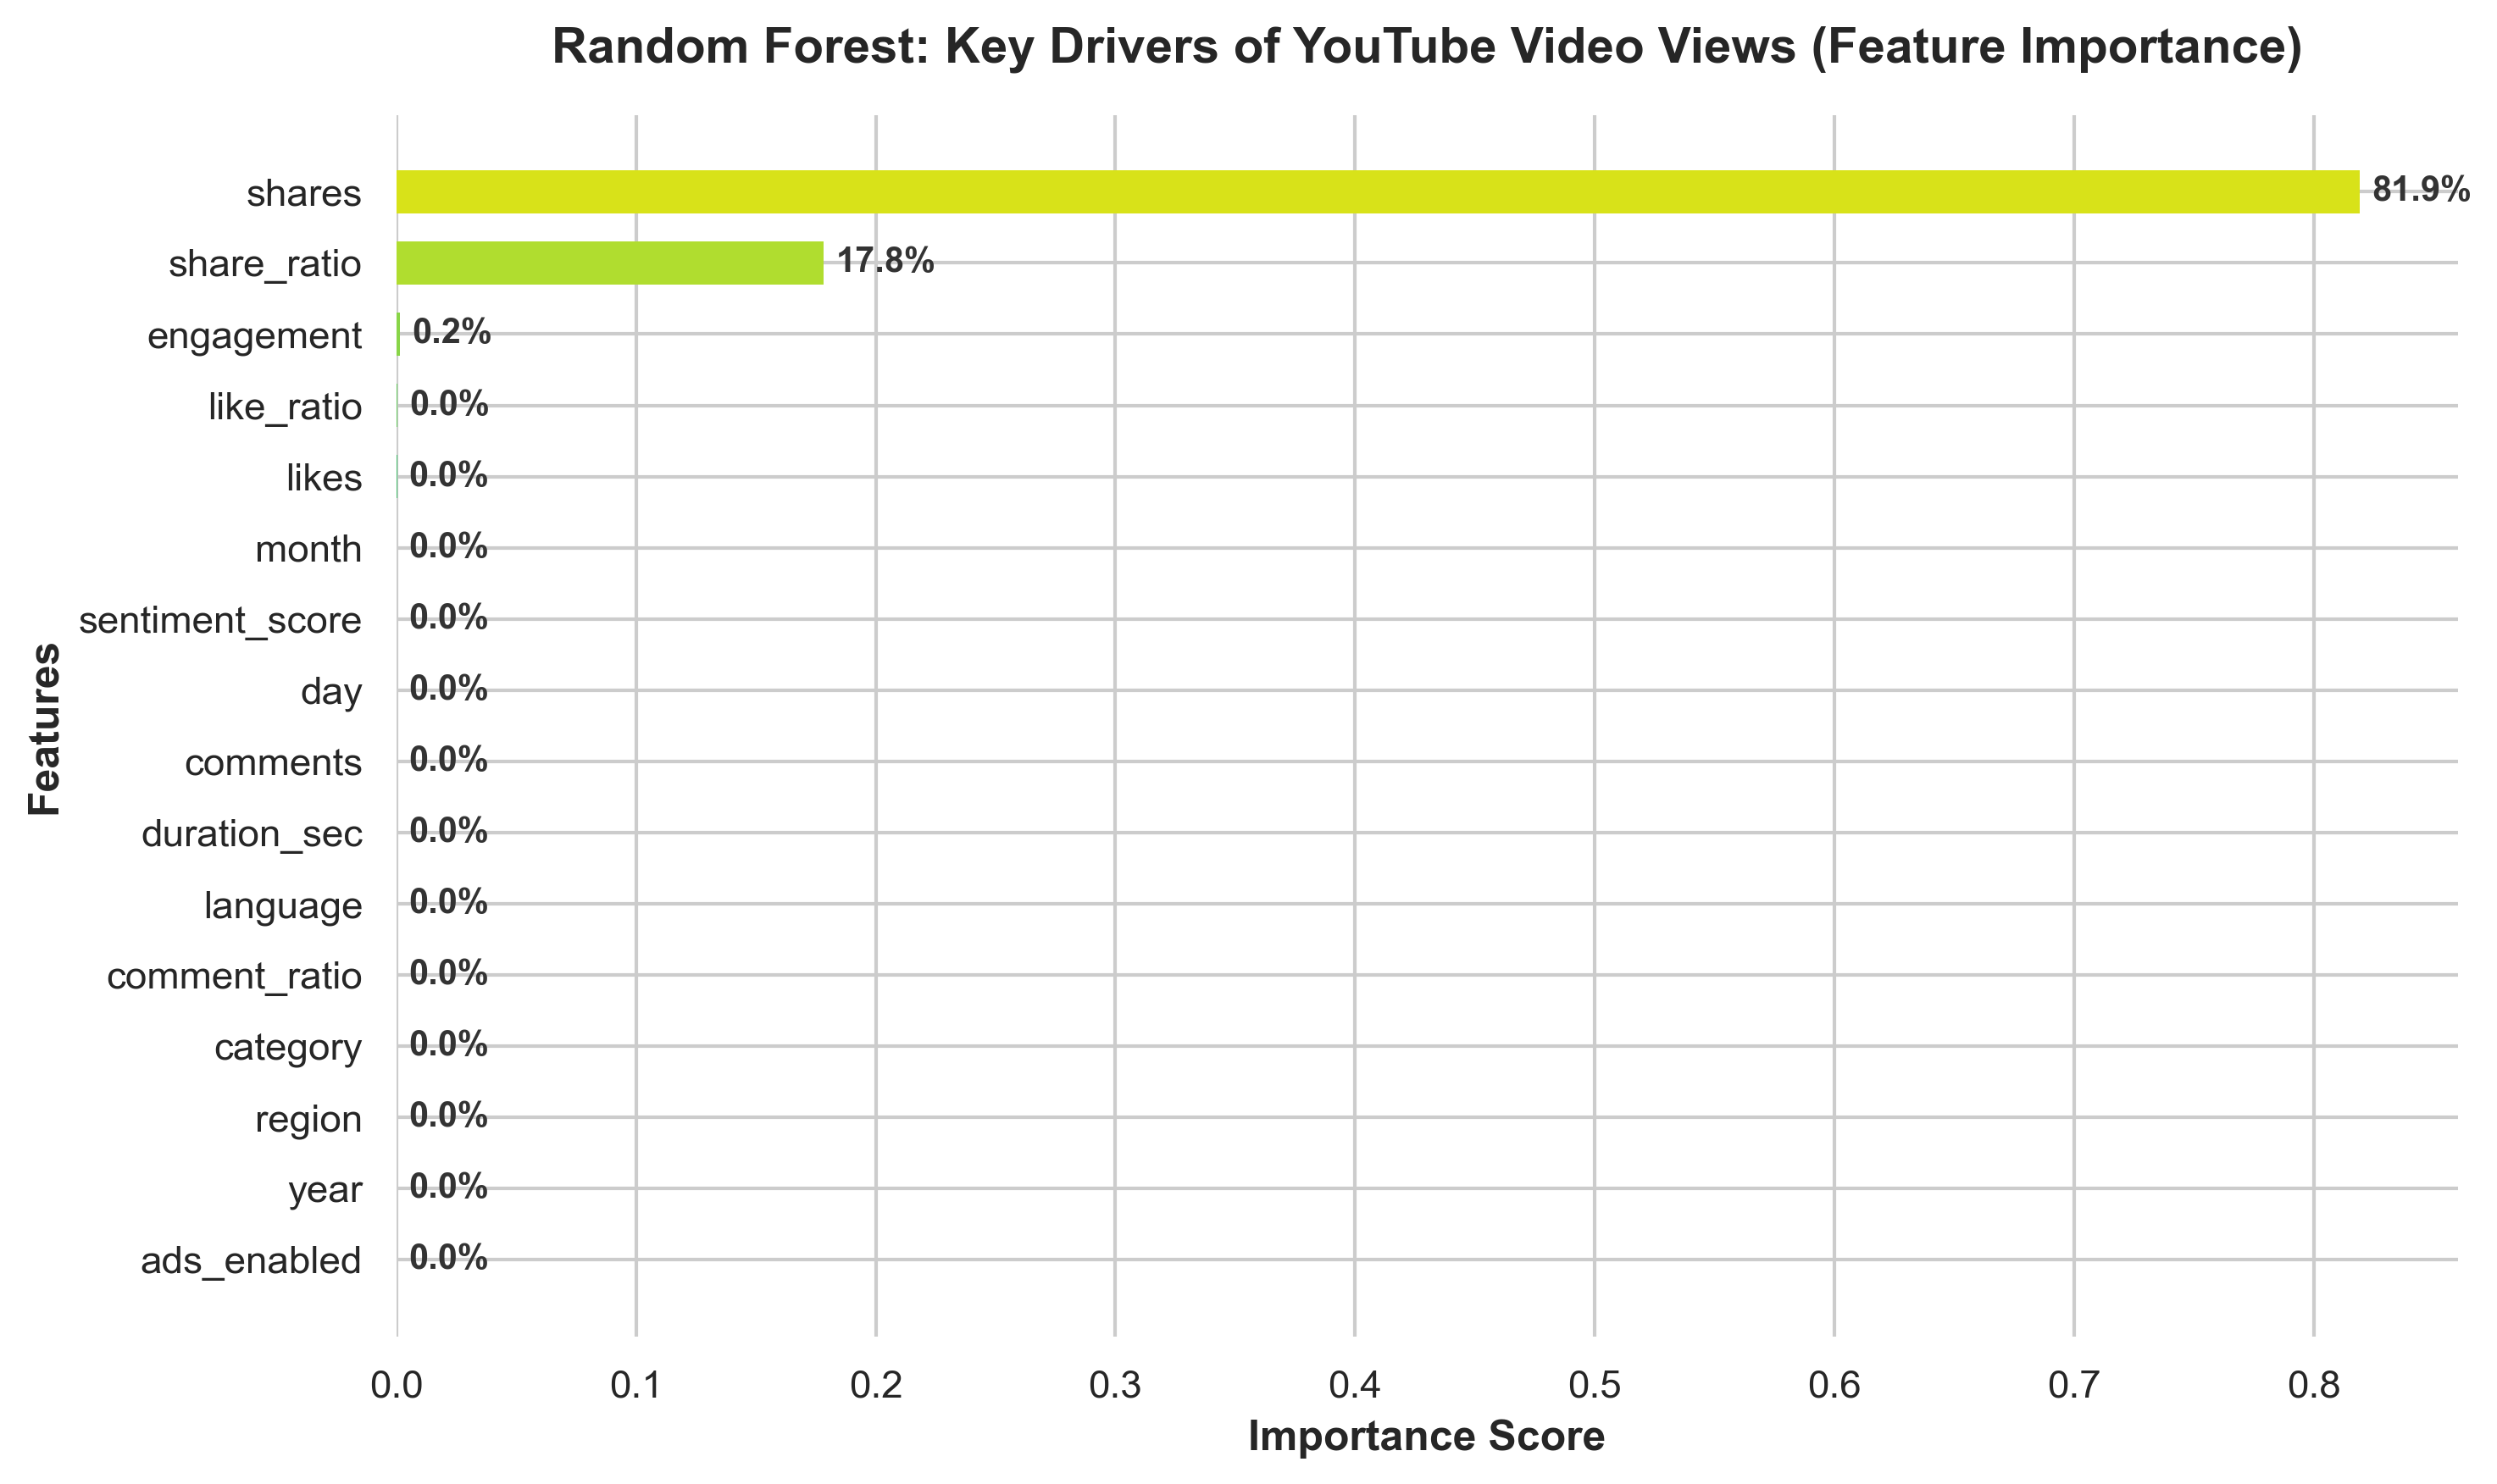

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate and sort feature importances

importances = RF.feature_importances_
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=True) 

# Plotting the horizontal bar chart
plt.figure(figsize=(10, 6), dpi=300)
colors = sns.color_palette("viridis", len(features_df)) 

bars = plt.barh(features_df['Feature'], features_df['Importance'], color=colors, edgecolor='none', height=0.6)

# Append percentage labels to the end of each bar for advanced look
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width*100:.1f}%', 
             va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')

# English labels and minimalist design
plt.title('Random Forest: Key Drivers of YouTube Video Views (Feature Importance)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
sns.despine(left=True, bottom=True) 
plt.tight_layout()

# Save image
plt.savefig('rf_feature_importance.png', dpi=300)
plt.show()

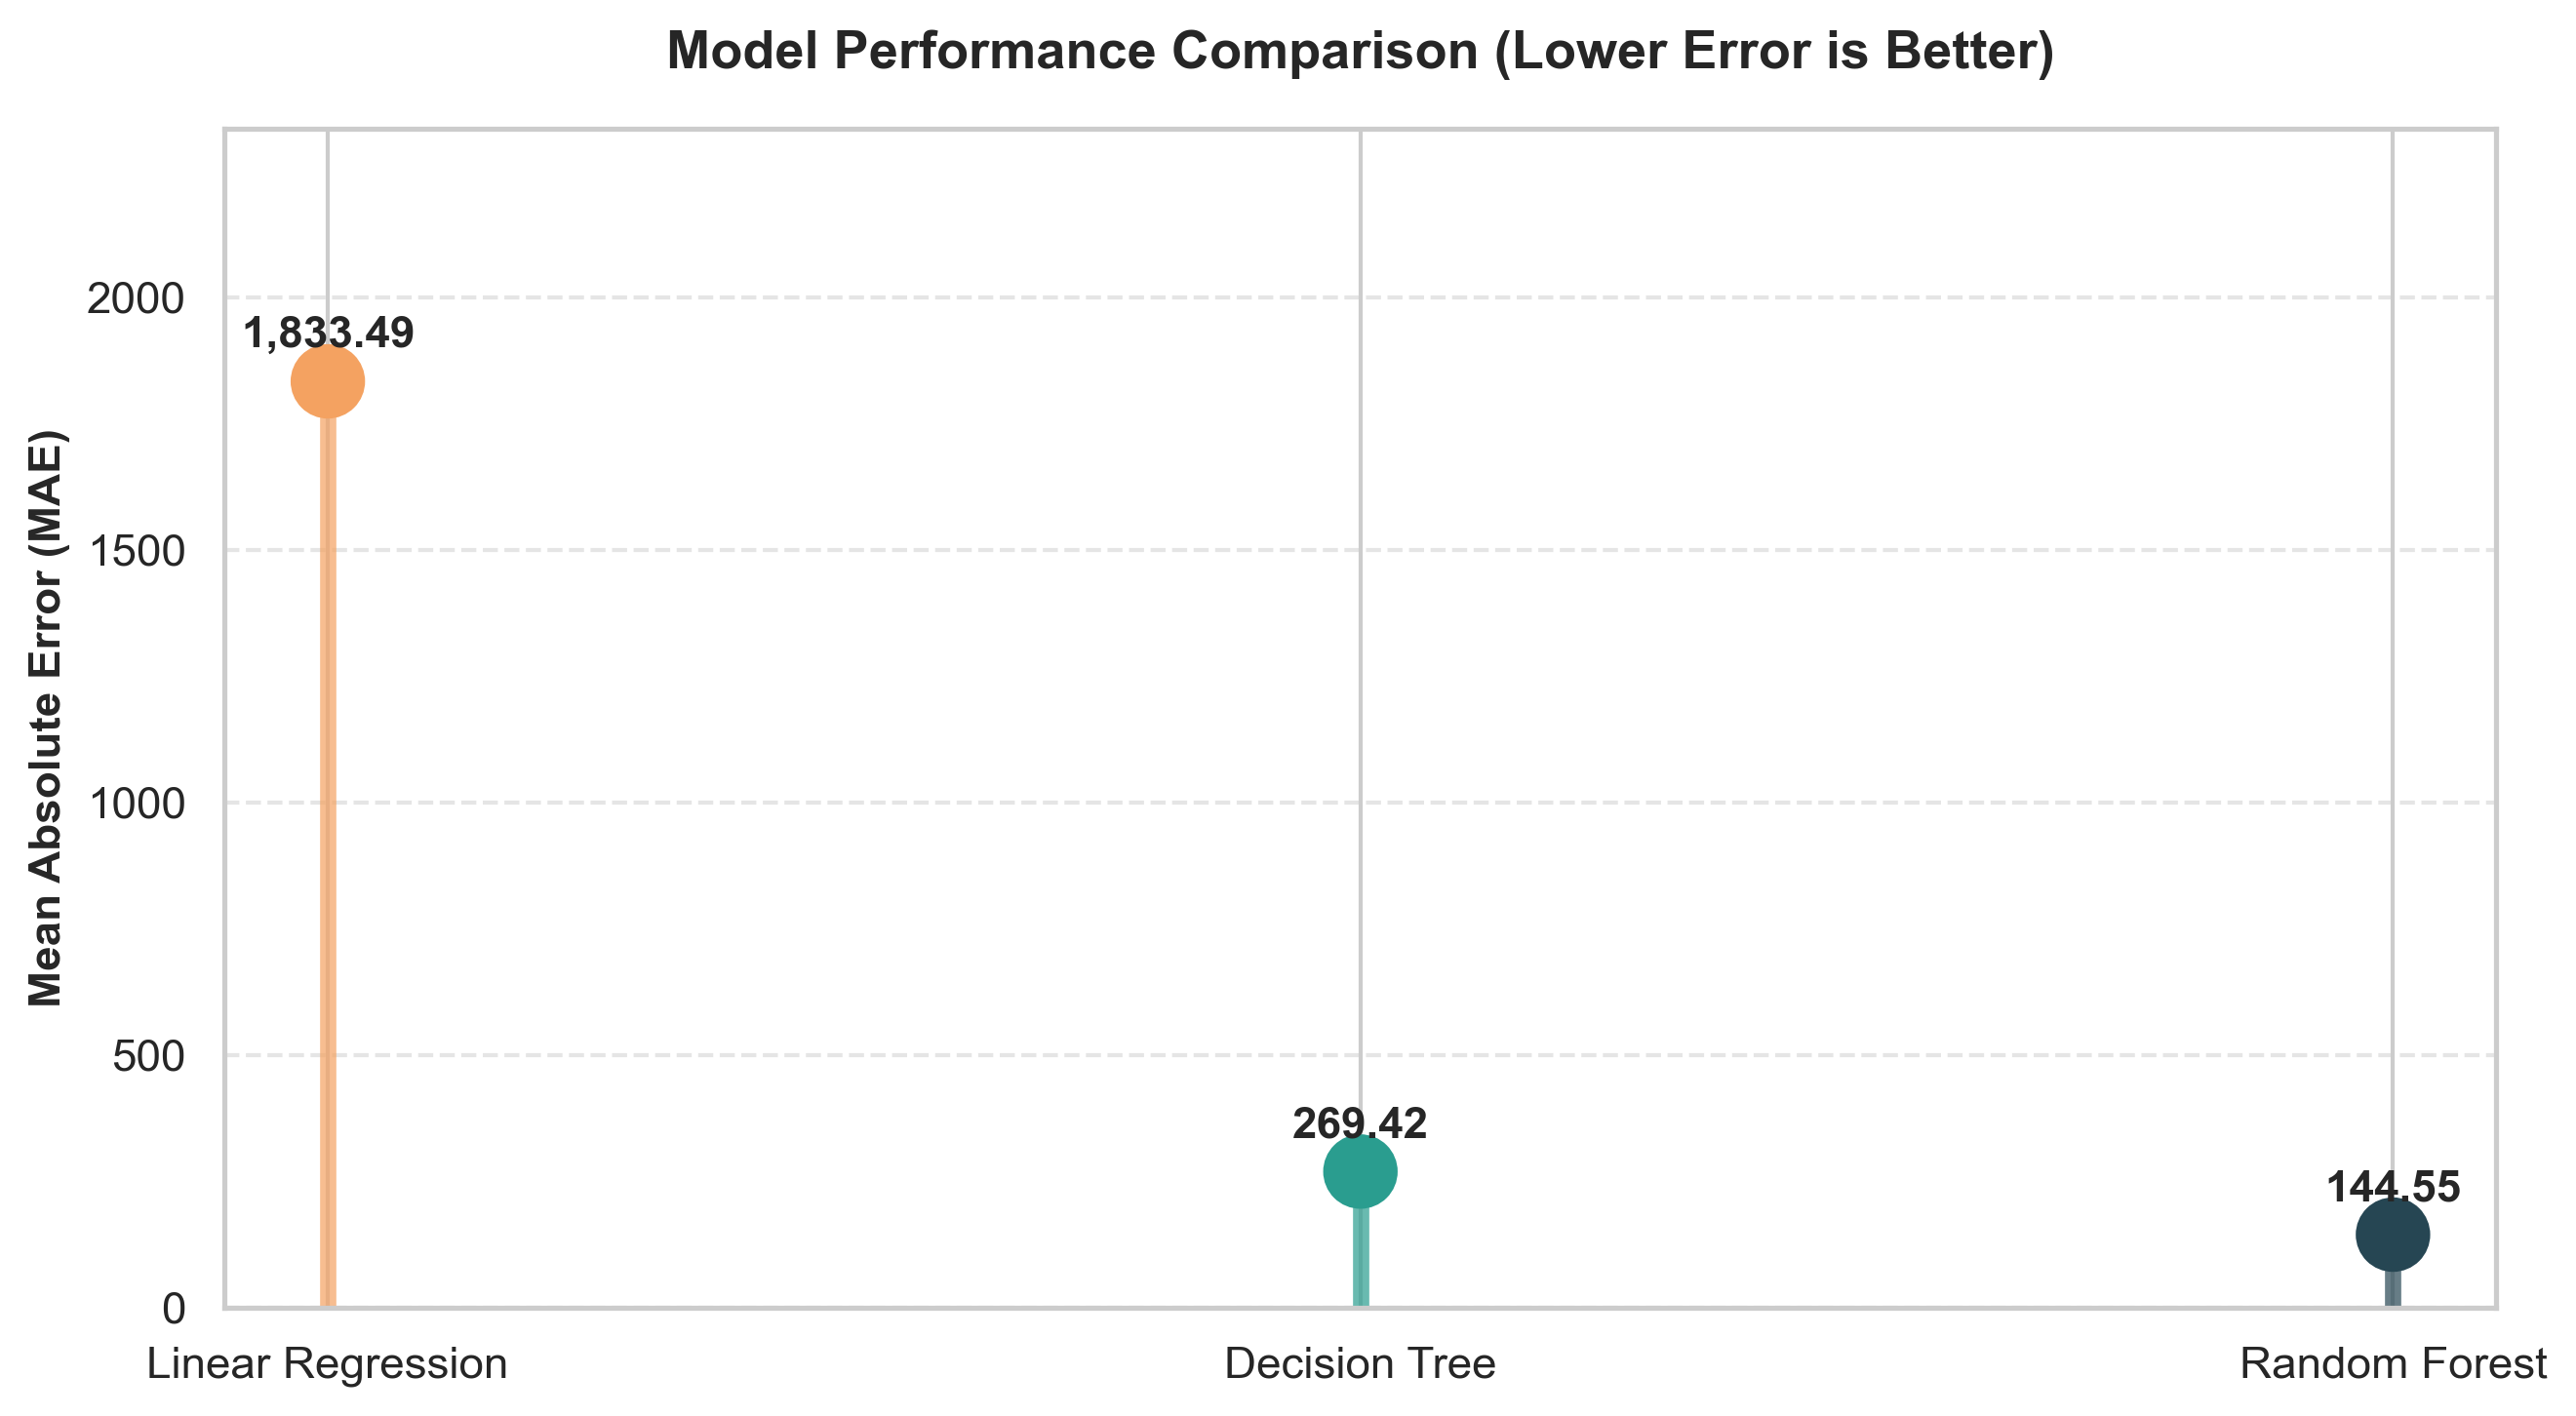

In [62]:
import matplotlib.pyplot as plt

# Define model names and their respective MAE scores
# Replace these values with your actual calculated test errors (MAE)
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
mae_values = [1833.4925264478725, 269.42450963784444, 144.5451494051896] 

plt.figure(figsize=(9, 5), dpi=300)
# Modern palette for digital portfolios
colors = ['#f4a261', '#2a9d8f', '#264653']

# Drawing the Lollipop chart elements
plt.scatter(models, mae_values, color=colors, s=300, zorder=3) 
plt.vlines(models, ymin=0, ymax=mae_values, color=colors, linewidth=4, alpha=0.7) 

# Display the exact error values on top of each marker
for i, val in enumerate(mae_values):
    plt.text(i, val + 50, f'{val:,.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Titles and layout styling
plt.title('Model Performance Comparison (Lower Error is Better)', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Mean Absolute Error (MAE)', fontsize=11, fontweight='bold')
plt.ylim(0, max(mae_values) + 500)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save image
plt.savefig('models_comparison.png', dpi=300)
plt.show()

In [64]:
import joblib

# Export the final selected model (Random Forest Regressor)
joblib.dump(RF, 'youtube_RandomForest_Regressor_Model.pkl')

print("Model saved successfully as youtube_RandomForest_Regressor_Model.pkl")

Model saved successfully as youtube_RandomForest_Regressor_Model.pkl
